# Part 2 — Model Building & Evaluation (Regression)

**Target:** `surv6m` (6-month survival probability, continuous, ∈ [0, 0.948])
**Dataset:** SUPPORT2 — cleaned splits produced by `code.ipynb`.
**Baseline to beat:** Part 1 XGBoost — RMSE 0.1086, R² 0.8170.

Sections:
1. Setup & data load
2. Feature schema + preprocessor
3. CV strategy + helper utilities
4. Part 1 baseline sanity check
5. Untuned benchmark (7 models)
6. Hyperparameter tuning (top 3 → top 1)
7. Final test-set evaluation
8. Residual diagnostics
9. Clinical-threshold secondary metrics
10. Feature importance (SHAP, permutation, linear coefs)
11. Artifacts & reproducibility
12. Verification (PASS/FAIL)


## 1. Setup

Imports, random seeds, artifact/figure directories, version prints.


In [1]:
# %pip install lightgbm

In [2]:
# %pip install shap

In [3]:
import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import logit, expit

import joblib

import sklearn
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV,
)
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, explained_variance_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

import xgboost as xgb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path(".").resolve()
ART  = ROOT / "artifacts"; ART.mkdir(exist_ok=True)
FIG  = ROOT / "figures";   FIG.mkdir(exist_ok=True)

# Optional libraries ----------------------------------------------------------
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print(f"LightGBM unavailable ({e!r}); that model will be skipped.")

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    HAS_SHAP = False
    print(f"SHAP unavailable ({e!r}); will use permutation importance only.")

versions = {
    "numpy":   np.__version__,
    "pandas":  pd.__version__,
    "sklearn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "lightgbm": (lgb.__version__ if HAS_LGBM else "not installed"),
    "shap":    (shap.__version__ if HAS_SHAP else "not installed"),
}
for k, v in versions.items():
    print(f"{k:>8}: {v}")


SHAP unavailable (AttributeError("module 'socketserver' has no attribute 'UnixStreamServer'")); will use permutation importance only.
   numpy: 2.0.2
  pandas: 3.0.1
 sklearn: 1.6.1
 xgboost: 3.2.0
lightgbm: 4.6.0
    shap: not installed


## 2. Load cleaned splits

Loads the parquet/CSV files persisted by the final cell of `code.ipynb`.
Fails loudly if they do not exist — re-run Part 1 first.


In [4]:
def _load(stem):
    pq = ART / f"{stem}.parquet"
    cs = ART / f"{stem}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if cs.exists():
        return pd.read_csv(cs, index_col=0)
    raise FileNotFoundError(
        f"Missing {stem}.parquet and {stem}.csv in {ART}. "
        "Run the final cell of code.ipynb to persist the cleaned splits."
    )

# train_df = _load("train_clean")
# test_df  = _load("test_clean")

file_path_train = os.path.join('..', 'datasets', 'train_df_processed.csv')
file_path_test = os.path.join('..', 'datasets', 'test_df_processed.csv')


train_df = pd.read_csv(file_path_train)
test_df  = pd.read_csv(file_path_test)

In [5]:
train_df.isnull().sum()

age                            0
sex                            0
num.co                         0
edu                            0
income                         0
scoma                          0
charges                        0
totmcst                        0
avtisst                       63
aps                            0
surv6m                         0
hday                           0
diabetes                       0
dementia                       0
ca                             0
meanbp                         0
wblc                           0
hrt                            0
resp                           1
temp                           0
pafi                           0
alb                            0
bili                           0
crea                           0
sod                            0
ph                             0
glucose                        0
bun                            0
urine                          0
adlsc                          0
dzclass_CO

In [41]:
test_df.isnull().sum()

age                            0
sex                            0
num.co                         0
edu                            0
income                         0
scoma                          0
charges                        0
totmcst                        0
avtisst                       18
aps                            0
surv6m                         0
hday                           0
diabetes                       0
dementia                       0
ca                             0
meanbp                         0
wblc                           0
hrt                            0
resp                           0
temp                           0
pafi                           0
alb                            0
bili                           0
crea                           0
sod                            0
ph                             0
glucose                        0
bun                            0
urine                          0
adlsc                          0
dzclass_CO

In [42]:
train_df.shape, test_df.shape

((7283, 36), (1821, 36))

In [43]:
train_df = train_df[~train_df['avtisst'].isnull()]
test_df = test_df[~test_df['avtisst'].isnull()]

In [44]:
print("Train NaNs:", train_df.isnull().sum().sum())
print("Test NaNs:", test_df.isnull().sum().sum())

Train NaNs: 1
Test NaNs: 0


In [45]:
train_df[train_df.isnull().any(axis=1)]

,age,sex,num.co,edu,income,scoma,charges,totmcst,avtisst,aps,...,glucose,bun,urine,adlsc,dzclass_COPD/CHF/Cirrhosis,dzclass_Coma,race_hispanic,race_other,race_white,dnr_dnr before sadm
5886,55.52597,1,2,12.0,0,0.0,92466.0,13378.7734,26.25,60.0,...,136.0,6.51,2502.0,7.0,False,False,False,False,True,False


In [46]:
train_df = train_df.dropna()

In [47]:
TARGET = "surv6m"
LEAKAGE = {"surv2m", "death", "hospdead", "sfdm2", "prg2m", "prg6m"}

assert train_df.isnull().sum().sum() == 0, "train_df has NaNs"
assert test_df.isnull().sum().sum()  == 0, "test_df has NaNs"
assert LEAKAGE.isdisjoint(train_df.columns), "leakage column present"
assert TARGET in train_df.columns

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(float)
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET].astype(float)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("y_train range:", (float(y_train.min()), float(y_train.max())))
print("y_test  range:", (float(y_test.min()),  float(y_test.max())))

Train: (7219, 35)  Test: (1803, 35)
y_train range: (0.0, 0.943969727)
y_test  range: (0.0, 0.939941406)


## 3. Feature schema

- **Binary / one-hot:** columns with `nunique() <= 2` — pass through.
- **Ordinal:** `income`, `ca` — scale for linear/SVR/NN, passthrough for trees.
- **Continuous:** everything else — scale for linear/SVR/NN, passthrough for trees.


In [48]:
ORDINAL = [c for c in ("income", "ca") if c in X_train.columns]
binary  = [c for c in X_train.columns if X_train[c].nunique() <= 2]
continuous = [c for c in X_train.columns if c not in binary + ORDINAL]

print(f"Binary   ({len(binary)}):    {binary}")
print(f"Ordinal  ({len(ORDINAL)}):   {ORDINAL}")
print(f"Continuous ({len(continuous)}): {continuous}")

assert len(binary) + len(ORDINAL) + len(continuous) == X_train.shape[1]


Binary   (9):    ['sex', 'diabetes', 'dementia', 'dzclass_COPD/CHF/Cirrhosis', 'dzclass_Coma', 'race_hispanic', 'race_other', 'race_white', 'dnr_dnr before sadm']
Ordinal  (2):   ['income', 'ca']
Continuous (24): ['age', 'num.co', 'edu', 'scoma', 'charges', 'totmcst', 'avtisst', 'aps', 'hday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc']


## 4. Preprocessor, CV splitter, helper functions

- `make_preprocessor(scale)` — scaling ColumnTransformer used by linear/SVR/NN;
  passthrough variant used by tree models (kept for pipeline uniformity).
- 5-fold StratifiedKFold on the same quantile bins Part 1 used.
- `logit_safe` / `expit` wrappers for `TransformedTargetRegressor`.
- `evaluate()` — runs CV, fits on full train, predicts on test (with clipping),
  computes all metrics, returns a one-row dict.


In [49]:
EPS = 1e-3
CLIP_HI = float(y_train.max())   # matches the Part 1 cap
CLIP_LO = 0.0

def make_preprocessor(scale: bool) -> ColumnTransformer:
    if scale:
        return ColumnTransformer(
            transformers=[
                ("scale", StandardScaler(), continuous + ORDINAL),
                ("pass",  "passthrough",    binary),
            ],
            remainder="drop",
        )
    return ColumnTransformer(
        transformers=[("pass", "passthrough", continuous + ORDINAL + binary)],
        remainder="drop",
    )

def logit_safe(y):
    return logit(np.clip(y, EPS, 1 - EPS))

# CV splitter
y_bin_train = pd.qcut(y_train, q=5, labels=False, duplicates="drop")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CV_SPLITS = list(cv.split(X_train, y_bin_train))

def clip_pred(p):
    return np.clip(p, CLIP_LO, CLIP_HI)

def metrics_row(name: str, y_true, y_pred, cv_rmse=None, cv_rmse_std=None,
                fit_time_s=None):
    return {
        "model":        name,
        "cv_rmse_mean": cv_rmse,
        "cv_rmse_std":  cv_rmse_std,
        "test_mae":     mean_absolute_error(y_true, y_pred),
        "test_mse":     mean_squared_error(y_true, y_pred),
        "test_rmse":    np.sqrt(mean_squared_error(y_true, y_pred)),
        "test_r2":      r2_score(y_true, y_pred),
        "test_expvar":  explained_variance_score(y_true, y_pred),
        "fit_time_s":   fit_time_s,
    }

def cv_rmse(pipe) -> tuple[float, float]:
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=CV_SPLITS, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    return -scores.mean(), scores.std()

def evaluate(name: str, pipe) -> dict:
    t0 = time.time()
    cv_mean, cv_std = cv_rmse(pipe)
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0
    y_pred = clip_pred(pipe.predict(X_test))
    return metrics_row(name, y_test, y_pred, cv_mean, cv_std, fit_time), pipe, y_pred


## 5. Part 1 baseline sanity check

Re-fit the exact XGBoost configuration from `code.ipynb` cell 77 and confirm
we reproduce RMSE ≈ 0.1086. If this fails, the data hand-off is broken.


In [50]:
baseline_model = XGBRegressor(
    n_estimators=100, learning_rate=0.1, random_state=SEED, seed=SEED,
)
baseline_model.fit(X_train, y_train)
y_pred_baseline = clip_pred(baseline_model.predict(X_test))
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_baseline)))
baseline_r2   = float(r2_score(y_test, y_pred_baseline))
print(f"Baseline RMSE: {baseline_rmse:.4f}  (target 0.1086)")
print(f"Baseline R2:   {baseline_r2:.4f}    (target 0.8170)")
assert abs(baseline_rmse - 0.1086) < 5e-3, "Baseline drift > 5e-3 — data load off."


Baseline RMSE: 0.1085  (target 0.1086)
Baseline R2:   0.8166    (target 0.8170)


## 6. Untuned benchmark — 7 models

Each model is wrapped in `Pipeline([('pre', preprocessor), ('model', est)])`.
Linear / SVR / MLP models also get a logit-transform variant via
`TransformedTargetRegressor`.


In [51]:
pre_scale = make_preprocessor(scale=True)
pre_none  = make_preprocessor(scale=False)

def tt(est):
    return TransformedTargetRegressor(
        regressor=est, func=logit_safe, inverse_func=expit,
    )

benchmark = {}

# Linear family -------------------------------------------------------------
benchmark["Ridge"] = Pipeline([
    ("pre", make_preprocessor(True)),
    ("model", Ridge(alpha=1.0, random_state=SEED)),
])
benchmark["Ridge_logit"] = Pipeline([
    ("pre", make_preprocessor(True)),
    ("model", tt(Ridge(alpha=1.0, random_state=SEED))),
])
benchmark["ElasticNet"] = Pipeline([
    ("pre", make_preprocessor(True)),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=SEED)),
])

# Tree ensembles ------------------------------------------------------------
benchmark["RandomForest"] = Pipeline([
    ("pre", make_preprocessor(False)),
    ("model", RandomForestRegressor(
        n_estimators=400, n_jobs=-1, random_state=SEED,
    )),
])
benchmark["XGBoost"] = Pipeline([
    ("pre", make_preprocessor(False)),
    ("model", XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        random_state=SEED, seed=SEED, n_jobs=-1,
    )),
])
benchmark["HistGradientBoosting"] = Pipeline([
    ("pre", make_preprocessor(False)),
    ("model", HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, random_state=SEED,
    )),
])
if HAS_LGBM:
    benchmark["LightGBM"] = Pipeline([
        ("pre", make_preprocessor(False)),
        ("model", LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            random_state=SEED, n_jobs=-1, verbose=-1,
        )),
    ])

# Neural --------------------------------------------------------------------
benchmark["MLP_logit"] = Pipeline([
    ("pre", make_preprocessor(True)),
    ("model", tt(MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=400, early_stopping=True,
        random_state=SEED,
    ))),
])

results = []
fitted  = {}
preds   = {}
for name, pipe in benchmark.items():
    row, fitted_pipe, y_pred = evaluate(name, pipe)
    results.append(row)
    fitted[name] = fitted_pipe
    preds[name]  = y_pred
    print(f"{name:>22}: CV_RMSE={row['cv_rmse_mean']:.4f}  "
          f"test_RMSE={row['test_rmse']:.4f}  test_R2={row['test_r2']:.4f}")

bench_df = pd.DataFrame(results).sort_values("cv_rmse_mean").reset_index(drop=True)
bench_df.to_csv(ART / "benchmark_summary.csv", index=False)
bench_df


                 Ridge: CV_RMSE=0.1333  test_RMSE=0.1337  test_R2=0.7216
           Ridge_logit: CV_RMSE=0.1419  test_RMSE=0.1413  test_R2=0.6893
            ElasticNet: CV_RMSE=0.1365  test_RMSE=0.1362  test_R2=0.7113
          RandomForest: CV_RMSE=0.1196  test_RMSE=0.1167  test_R2=0.7879
               XGBoost: CV_RMSE=0.1092  test_RMSE=0.1076  test_R2=0.8197
  HistGradientBoosting: CV_RMSE=0.1081  test_RMSE=0.1068  test_R2=0.8226
              LightGBM: CV_RMSE=0.1085  test_RMSE=0.1065  test_R2=0.8235
             MLP_logit: CV_RMSE=0.1289  test_RMSE=0.1241  test_R2=0.7601


,model,cv_rmse_mean,cv_rmse_std,test_mae,test_mse,test_rmse,test_r2,test_expvar,fit_time_s
0,HistGradientBoosting,0.108120,0.003126,0.078189,0.011397,0.106755,0.822553,0.822674,10.820465
1,LightGBM,0.108521,0.003083,0.077341,0.011333,0.106455,0.823548,0.823744,8.582740
2,XGBoost,0.109180,0.002586,0.079252,0.011578,0.107600,0.819732,0.819870,2.389272
3,RandomForest,0.119563,0.002480,0.088219,0.013622,0.116713,0.787904,0.787971,43.356650
4,MLP_logit,0.128884,0.004479,0.090347,0.015406,0.124119,0.760133,0.760139,3.639227
5,Ridge,0.133300,0.002806,0.102004,0.017883,0.133727,0.721561,0.721771,4.969537
6,ElasticNet,0.136489,0.002497,0.104997,0.018539,0.136159,0.711340,0.711462,0.121030
7,Ridge_logit,0.141866,0.003328,0.107612,0.019956,0.141264,0.689290,0.696566,2.514327


## 7. Hyperparameter tuning

- Take the top 3 by CV RMSE.
- `RandomizedSearchCV(n_iter=40, cv=5)` per candidate.
- The overall winner gets a small `GridSearchCV` refinement.

The search spaces below are written for sklearn `Pipeline` steps — all keys are
prefixed with `model__` (or `model__regressor__` for a `TransformedTargetRegressor`).


In [53]:
TUNE_TOP_K = 3
TUNE_ITERS = 5

top_models = bench_df["model"].head(TUNE_TOP_K).tolist()
print("Tuning:", top_models)

SEARCH_SPACES = {
    "Ridge": {"model__alpha": np.logspace(-3, 3, 13)},
    "Ridge_logit": {"model__regressor__alpha": np.logspace(-3, 3, 13)},
    "ElasticNet": {
        "model__alpha":    np.logspace(-4, 1, 10),
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "RandomForest": {
        "model__n_estimators":     [300, 600],
        "model__max_depth":        [None, 8, 16],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features":     ["sqrt", 0.5, 1.0],
    },
    "XGBoost": {
        "model__n_estimators":     [300, 600, 1000],
        "model__max_depth":        [3, 5, 7, 9],
        "model__learning_rate":    [0.01, 0.03, 0.1],
        "model__subsample":        [0.7, 1.0],
        "model__colsample_bytree": [0.7, 1.0],
        "model__reg_lambda":       [0.1, 1, 10],
        "model__min_child_weight": [1, 5],
    },
    "HistGradientBoosting": {
        "model__max_iter":         [200, 400, 800],
        "model__max_depth":        [None, 5, 9],
        "model__learning_rate":    [0.01, 0.05, 0.1],
        "model__l2_regularization":[0.0, 1.0, 10.0],
    },
    "LightGBM": {
        "model__n_estimators":     [300, 600, 1000],
        "model__num_leaves":       [31, 63, 127],
        "model__learning_rate":    [0.01, 0.03, 0.1],
        "model__min_child_samples":[5, 20, 50],
        "model__feature_fraction": [0.7, 1.0],
    },
    "MLP_logit": {
        "model__regressor__hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
        "model__regressor__alpha":              [1e-4, 1e-3, 1e-2],
        "model__regressor__learning_rate_init": [1e-3, 5e-4],
    },
}

tuned_results = []
tuned_fitted  = {}
tuned_preds   = {}

for name in top_models:
    space = SEARCH_SPACES.get(name)
    if not space:
        print(f"No search space for {name}, skipping.")
        continue
    pipe = benchmark[name]
    n_combos = 1
    for v in space.values():
        n_combos *= len(list(v))
    n_iter = min(TUNE_ITERS, n_combos)
    print(f"Tuning {name} — {n_iter}/{n_combos} combos × 5 folds")

    search = RandomizedSearchCV(
        pipe, space, n_iter=n_iter, cv=CV_SPLITS,
        scoring="neg_root_mean_squared_error",
        random_state=SEED, n_jobs=-1, refit=True, verbose=0,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    fit_time = time.time() - t0

    pd.DataFrame(search.cv_results_).to_csv(
        ART / f"cv_results_{name}.csv", index=False,
    )
    best = search.best_estimator_
    y_pred = clip_pred(best.predict(X_test))
    row = metrics_row(
        f"{name}_tuned", y_test, y_pred,
        -search.best_score_, None, fit_time,
    )
    tuned_results.append(row)
    tuned_fitted[name] = best
    tuned_preds[name]  = y_pred
    print(f"  best CV_RMSE={-search.best_score_:.4f}  "
          f"test_RMSE={row['test_rmse']:.4f}")
    print(f"  best params: {search.best_params_}")

tuned_df = pd.DataFrame(tuned_results).sort_values("test_rmse")
tuned_df


Tuning: ['HistGradientBoosting', 'LightGBM', 'XGBoost']
Tuning HistGradientBoosting — 5/81 combos × 5 folds
  best CV_RMSE=0.1089  test_RMSE=0.1083
  best params: {'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}
Tuning LightGBM — 5/162 combos × 5 folds
  best CV_RMSE=0.1093  test_RMSE=0.1090
  best params: {'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 5, 'model__learning_rate': 0.1, 'model__feature_fraction': 0.7}
Tuning XGBoost — 5/864 combos × 5 folds
  best CV_RMSE=0.1080  test_RMSE=0.1066
  best params: {'model__subsample': 0.7, 'model__reg_lambda': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


,model,cv_rmse_mean,cv_rmse_std,test_mae,test_mse,test_rmse,test_r2,test_expvar,fit_time_s
2,XGBoost_tuned,0.108009,None,0.079018,0.011371,0.106635,0.822952,0.823021,47.515776
0,HistGradientBoosting_tuned,0.108933,None,0.078754,0.011728,0.108296,0.817393,0.817580,21.809331
1,LightGBM_tuned,0.109269,None,0.079662,0.011871,0.108955,0.815163,0.815335,67.916323


### 7.1 Grid refinement for the overall winner


In [54]:
if len(tuned_df):
    winner_name = tuned_df.iloc[0]["model"].replace("_tuned", "")
    winner_pipe = tuned_fitted[winner_name]
    winner_params = {k: [v] for k, v in winner_pipe.get_params().items()
                     if k in SEARCH_SPACES[winner_name]}
    # Nothing to grid over if winner already at single point — skip refinement.
    refinable = [k for k, v in SEARCH_SPACES[winner_name].items()
                 if len(list(v)) > 1]
    if refinable and winner_name in ("XGBoost", "LightGBM", "RandomForest",
                                     "HistGradientBoosting"):
        base = {k: [winner_pipe.get_params()[k]] for k in SEARCH_SPACES[winner_name]}
        # Expand one numeric hyperparam ± one step for refinement
        lr_keys = [k for k in refinable if "learning_rate" in k]
        if lr_keys:
            lr_key = lr_keys[0]
            cur = winner_pipe.get_params()[lr_key]
            base[lr_key] = sorted({cur * 0.5, cur, cur * 1.5})
        grid = GridSearchCV(
            winner_pipe, base, cv=CV_SPLITS,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1, refit=True, verbose=0,
        )
        grid.fit(X_train, y_train)
        final_model = grid.best_estimator_
        final_name  = f"{winner_name}_refined"
        y_pred = clip_pred(final_model.predict(X_test))
        tuned_results.append(metrics_row(
            final_name, y_test, y_pred, -grid.best_score_, None, None,
        ))
        tuned_fitted[winner_name] = final_model
        tuned_preds[winner_name]  = y_pred
        print(f"Refinement: {final_name} CV_RMSE={-grid.best_score_:.4f}")
    else:
        final_model = winner_pipe
        final_name  = f"{winner_name}_tuned"
        print(f"No grid refinement needed; sticking with {final_name}.")
else:
    raise RuntimeError("No tuned models produced — check previous cell.")

FINAL_NAME  = final_name
FINAL_PIPE  = final_model
FINAL_PRED  = clip_pred(FINAL_PIPE.predict(X_test))
print("Final model:", FINAL_NAME)


Refinement: XGBoost_refined CV_RMSE=0.1074
Final model: XGBoost_refined


## 8. Final results summary

Write `results_summary.csv` combining benchmark + tuned rows. Also report
raw (pre-clip) prediction range per model so bound-violation is visible.


In [55]:
# Raw prediction ranges (pre-clip) for transparency
raw_ranges = {}
for name, pipe in {**fitted, **tuned_fitted}.items():
    raw = pipe.predict(X_test)
    raw_ranges[name] = (float(raw.min()), float(raw.max()))

summary = pd.concat([bench_df, pd.DataFrame(tuned_results)], ignore_index=True)
summary["raw_pred_min"] = summary["model"].map(
    lambda n: raw_ranges.get(n.replace("_tuned","").replace("_refined",""), (np.nan,np.nan))[0]
)
summary["raw_pred_max"] = summary["model"].map(
    lambda n: raw_ranges.get(n.replace("_tuned","").replace("_refined",""), (np.nan,np.nan))[1]
)
summary = summary.sort_values("test_rmse").reset_index(drop=True)
summary.to_csv(ART / "results_summary.csv", index=False)
summary


,model,cv_rmse_mean,cv_rmse_std,test_mae,test_mse,test_rmse,test_r2,test_expvar,fit_time_s,raw_pred_min,raw_pred_max
0,LightGBM,0.108521,0.003083,0.077341,0.011333,0.106455,0.823548,0.823744,8.582740,-0.092162,0.954385
1,XGBoost_refined,0.107356,None,0.078392,0.011344,0.106510,0.823368,0.823441,NaN,-0.069533,0.970102
2,XGBoost_tuned,0.108009,None,0.079018,0.011371,0.106635,0.822952,0.823021,47.515776,-0.069533,0.970102
3,HistGradientBoosting,0.108120,0.003126,0.078189,0.011397,0.106755,0.822553,0.822674,10.820465,-0.106814,0.958247
4,XGBoost,0.109180,0.002586,0.079252,0.011578,0.107600,0.819732,0.819870,2.389272,-0.069533,0.970102
5,HistGradientBoosting_tuned,0.108933,None,0.078754,0.011728,0.108296,0.817393,0.817580,21.809331,-0.106814,0.958247
6,LightGBM_tuned,0.109269,None,0.079662,0.011871,0.108955,0.815163,0.815335,67.916323,-0.092162,0.954385
7,RandomForest,0.119563,0.00248,0.088219,0.013622,0.116713,0.787904,0.787971,43.356650,0.002555,0.900048
8,MLP_logit,0.128884,0.004479,0.090347,0.015406,0.124119,0.760133,0.760139,3.639227,0.000318,0.917167
9,Ridge,0.133300,0.002806,0.102004,0.017883,0.133727,0.721561,0.721771,4.969537,-0.326495,0.995245


## 8.1 Reliability — bootstrap 95% CI and paired test vs baseline

- **Bootstrap 95% CI** on final-model RMSE (1,000 resamples of the test set).
- **Paired bootstrap test** of `final_rmse − baseline_rmse` (both models share the
  same test set; pair residuals by index). Reports a two-sided p-value for
  H₀: models are equivalent in RMSE.
- **Paired Wilcoxon signed-rank** on the absolute-error vector as a
  distribution-free cross-check.


              final_rmse: 0.106510
      final_rmse_ci95_lo: 0.101356
      final_rmse_ci95_hi: 0.111497
           baseline_rmse: 0.108539
   diff_final_minus_base: -0.002030
            diff_ci95_lo: -0.003544
            diff_ci95_hi: -0.000510
             bootstrap_p: 0.012000
           wilcoxon_stat: 735685.000000
              wilcoxon_p: 0.001377


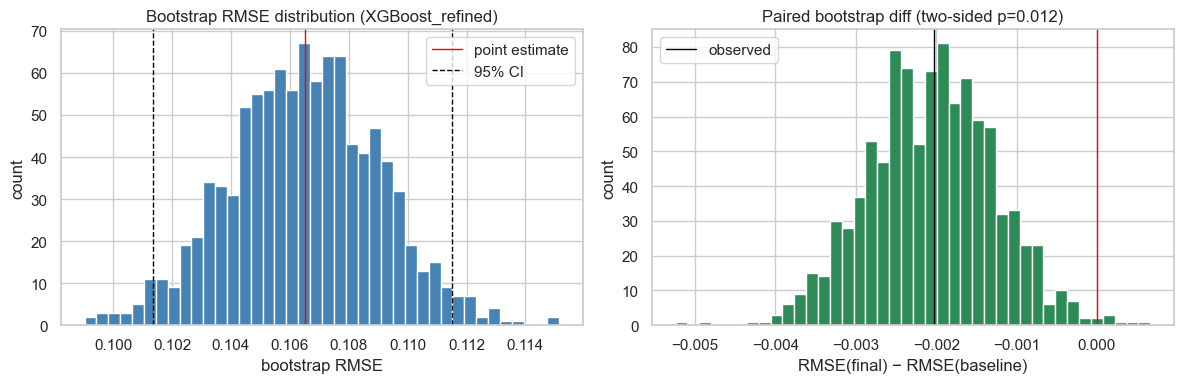

In [56]:
N_BOOT = 1000
rng = np.random.default_rng(SEED)

y_arr   = y_test.values
base_p  = y_pred_baseline            # from Section 5
final_p = FINAL_PRED

def rmse(y, p):
    return float(np.sqrt(np.mean((y - p) ** 2)))

# Bootstrap CI on final-model RMSE
boot_rmse = np.empty(N_BOOT)
n = len(y_arr)
for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    boot_rmse[b] = rmse(y_arr[idx], final_p[idx])
ci_lo, ci_hi = np.quantile(boot_rmse, [0.025, 0.975])

# Paired bootstrap test on (final - baseline) RMSE difference
observed_diff = rmse(y_arr, final_p) - rmse(y_arr, base_p)
boot_diff = np.empty(N_BOOT)
for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    boot_diff[b] = rmse(y_arr[idx], final_p[idx]) - rmse(y_arr[idx], base_p[idx])
# Two-sided p-value: fraction of bootstrap diffs with opposite sign to observed
if observed_diff < 0:
    p_boot = 2 * (boot_diff >= 0).mean()
else:
    p_boot = 2 * (boot_diff <= 0).mean()
p_boot = min(p_boot, 1.0)
diff_ci_lo, diff_ci_hi = np.quantile(boot_diff, [0.025, 0.975])

# Wilcoxon on absolute errors (paired)
abs_final = np.abs(y_arr - final_p)
abs_base  = np.abs(y_arr - base_p)
w_stat, w_p = stats.wilcoxon(abs_final, abs_base,
                             zero_method="wilcox", alternative="two-sided")

reliability = {
    "final_rmse":             rmse(y_arr, final_p),
    "final_rmse_ci95_lo":     float(ci_lo),
    "final_rmse_ci95_hi":     float(ci_hi),
    "baseline_rmse":          rmse(y_arr, base_p),
    "diff_final_minus_base":  observed_diff,
    "diff_ci95_lo":           float(diff_ci_lo),
    "diff_ci95_hi":           float(diff_ci_hi),
    "bootstrap_p":            float(p_boot),
    "wilcoxon_stat":          float(w_stat),
    "wilcoxon_p":             float(w_p),
}
pd.Series(reliability).to_csv(ART / "reliability.csv")
for k, v in reliability.items():
    print(f"{k:>24}: {v:.6f}" if isinstance(v, float) else f"{k:>24}: {v}")

# Plot bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_rmse, bins=40, color="steelblue")
axes[0].axvline(rmse(y_arr, final_p), color="red", lw=1, label="point estimate")
axes[0].axvline(ci_lo, color="black", ls="--", lw=1, label="95% CI")
axes[0].axvline(ci_hi, color="black", ls="--", lw=1)
axes[0].set(xlabel="bootstrap RMSE", ylabel="count",
            title=f"Bootstrap RMSE distribution ({FINAL_NAME})")
axes[0].legend()

axes[1].hist(boot_diff, bins=40, color="seagreen")
axes[1].axvline(0, color="red", lw=1)
axes[1].axvline(observed_diff, color="black", lw=1, label="observed")
axes[1].set(xlabel="RMSE(final) − RMSE(baseline)", ylabel="count",
            title="Paired bootstrap diff (two-sided p={:.3f})".format(p_boot))
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "reliability_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Residual diagnostics — final model

Predicted-vs-actual, residual hist, residual-vs-predicted, QQ plot, and
residuals broken out by `ca` and `dzclass_*`.


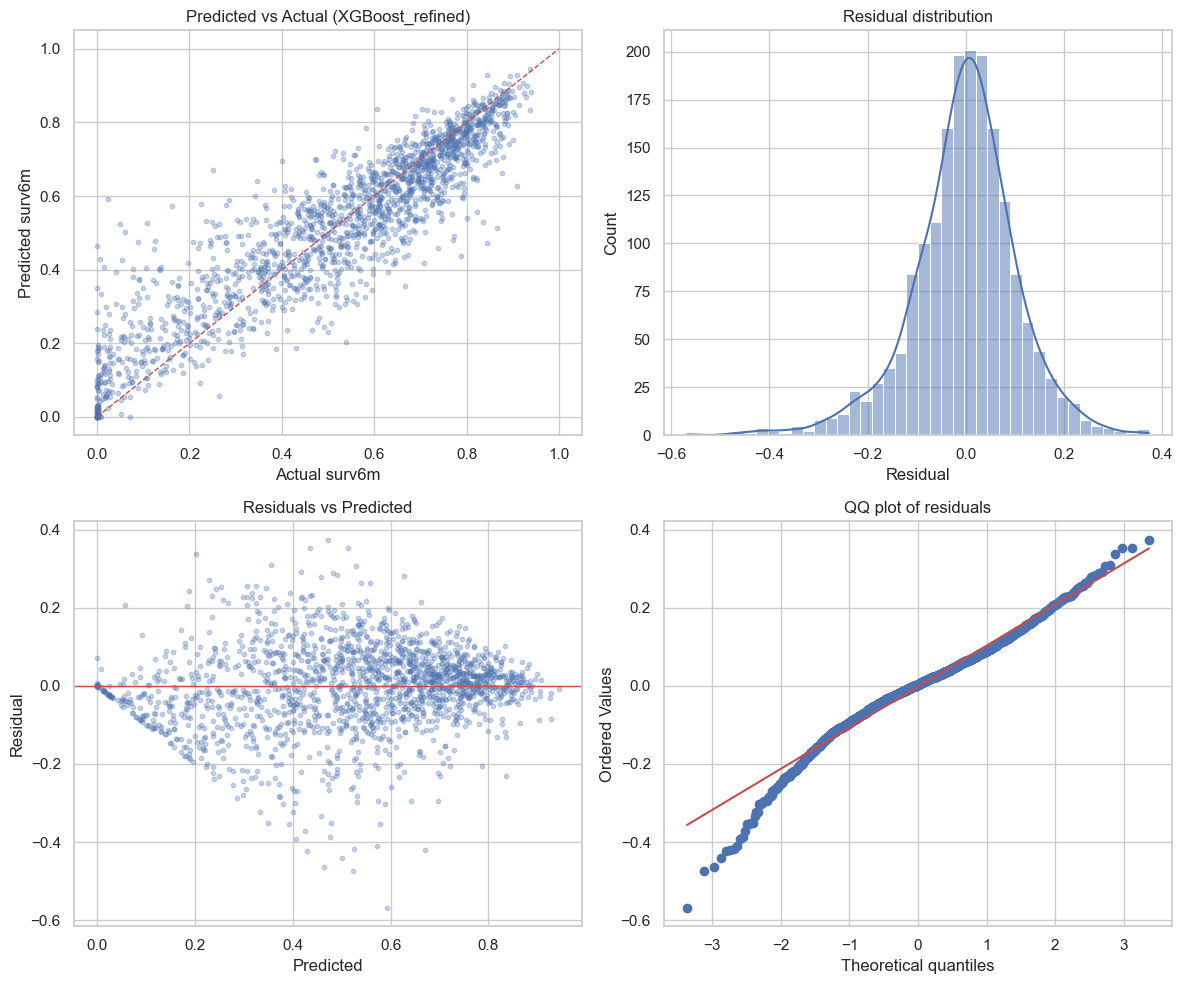

Residual mean by ca:
        mean       std  count
ca                           
0   0.000166  0.093111   1206
1   0.003692  0.102374    209
2  -0.012575  0.141628    388

Residual mean by dzclass:
                        group  mean_resid  std_resid    n
0  dzclass_COPD/CHF/Cirrhosis    0.002914   0.083556  580
1                dzclass_Coma    0.001468   0.080141  118


In [57]:
resid = y_test.values - FINAL_PRED

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(y_test, FINAL_PRED, alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], "r--", lw=1)
ax.set(xlabel="Actual surv6m", ylabel="Predicted surv6m",
       title=f"Predicted vs Actual ({FINAL_NAME})")

ax = axes[0, 1]
sns.histplot(resid, kde=True, ax=ax, bins=40)
ax.set(xlabel="Residual", title="Residual distribution")

ax = axes[1, 0]
ax.scatter(FINAL_PRED, resid, alpha=0.3, s=10)
ax.axhline(0, color="r", lw=1)
ax.set(xlabel="Predicted", ylabel="Residual",
       title="Residuals vs Predicted")

ax = axes[1, 1]
stats.probplot(resid, dist="norm", plot=ax)
ax.set(title="QQ plot of residuals")

plt.tight_layout()
plt.savefig(FIG / f"{FINAL_NAME}_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Subgroup residual means
print("Residual mean by ca:")
print(pd.DataFrame({"ca": X_test["ca"] if "ca" in X_test else np.zeros(len(X_test)),
                    "resid": resid}).groupby("ca")["resid"].agg(["mean","std","count"]))

dz_cols = [c for c in X_test.columns if c.startswith("dzclass_")]
if dz_cols:
    rows = []
    for c in dz_cols:
        m = X_test[c].astype(bool)
        rows.append({"group": c, "mean_resid": resid[m].mean(),
                     "std_resid": resid[m].std(), "n": int(m.sum())})
    print("\nResidual mean by dzclass:")
    print(pd.DataFrame(rows))


## 10. Clinical-threshold secondary metrics

Binarize `surv6m < 0.5` → "high risk / likely death within 6 months".
Use `1 - y_pred` as a death-risk score for ROC / PR.


   threshold: 0.5
          TP: 613
          FP: 127
          TN: 950
          FN: 113
 sensitivity: 0.8443526170798898
 specificity: 0.8820798514391829
         PPV: 0.8283783783783784
         NPV: 0.8936970837253058
     ROC_AUC: 0.9479103519366877
      PR_AUC: 0.9284460675031742


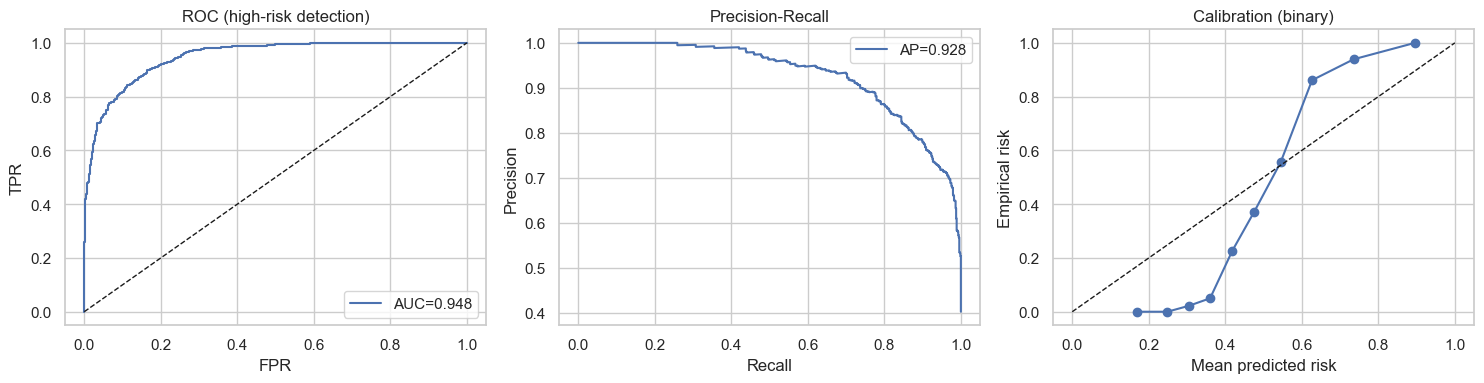

In [58]:
THRESH = 0.5

y_hi = (y_test < THRESH).astype(int)          # 1 = high risk
score = 1.0 - FINAL_PRED                       # higher = higher death risk

y_hat = (FINAL_PRED < THRESH).astype(int)
cm = confusion_matrix(y_hi, y_hat)
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp + fn) else float("nan")
spec = tn / (tn + fp) if (tn + fp) else float("nan")
ppv  = tp / (tp + fp) if (tp + fp) else float("nan")
npv  = tn / (tn + fn) if (tn + fn) else float("nan")
auc  = roc_auc_score(y_hi, score)
ap   = average_precision_score(y_hi, score)

clin = {
    "threshold": THRESH, "TP": int(tp), "FP": int(fp),
    "TN": int(tn), "FN": int(fn),
    "sensitivity": sens, "specificity": spec,
    "PPV": ppv, "NPV": npv, "ROC_AUC": auc, "PR_AUC": ap,
}
pd.Series(clin).to_csv(ART / "clinical_metrics.csv")
for k, v in clin.items():
    print(f"{k:>12}: {v}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fpr, tpr, _ = roc_curve(y_hi, score)
axes[0].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC (high-risk detection)")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_hi, score)
axes[1].plot(rec, prec, label=f"AP={ap:.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall")
axes[1].legend()

frac_pos, mean_pred = calibration_curve(y_hi, score, n_bins=10, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, marker="o")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set(xlabel="Mean predicted risk", ylabel="Empirical risk",
            title="Calibration (binary)")

plt.tight_layout()
plt.savefig(FIG / f"{FINAL_NAME}_clinical.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Feature importance (consolidated)

Three views:
1. **SHAP** — `TreeExplainer` for tree models, `LinearExplainer` for linear.
   Skipped gracefully if `shap` is unavailable.
2. **Permutation importance** — model-agnostic, on the test set.
3. **Standardized linear coefficients** — for tuned Ridge / ElasticNet if
   either was tuned.

Produces a consolidated rank table.


In [59]:
feature_names = list(X_train.columns)
ranks = pd.DataFrame({"feature": feature_names}).set_index("feature")

# --- Permutation importance -------------------------------------------------
perm = permutation_importance(
    FINAL_PIPE, X_test, y_test,
    n_repeats=20, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED,
)
perm_mean = pd.Series(perm.importances_mean, index=feature_names)
ranks["perm_importance"] = perm_mean
ranks["perm_rank"] = perm_mean.rank(ascending=False)

# --- SHAP -------------------------------------------------------------------
if HAS_SHAP:
    try:
        est = FINAL_PIPE.named_steps["model"]
        inner = est.regressor_ if hasattr(est, "regressor_") else est
        is_tree = any(cls in type(inner).__name__
                      for cls in ("XGB", "RandomForest", "Extra",
                                  "LGBM", "HistGradientBoosting"))
        # Transform test features through the preprocessor so SHAP sees the
        # same space the model trained on.
        X_test_t = FINAL_PIPE.named_steps["pre"].transform(X_test)
        if hasattr(X_test_t, "toarray"):
            X_test_t = X_test_t.toarray()
        if is_tree:
            explainer = shap.TreeExplainer(inner)
            shap_vals = explainer.shap_values(X_test_t)
        else:
            bg = shap.sample(FINAL_PIPE.named_steps["pre"]
                                        .transform(X_train), 200,
                             random_state=SEED)
            if hasattr(bg, "toarray"):
                bg = bg.toarray()
            explainer = shap.KernelExplainer(inner.predict, bg)
            shap_vals = explainer.shap_values(X_test_t[:500])
        abs_mean = np.abs(np.asarray(shap_vals)).mean(axis=0)
        shap_series = pd.Series(abs_mean[: len(feature_names)],
                                index=feature_names)
        ranks["shap_importance"] = shap_series
        ranks["shap_rank"] = shap_series.rank(ascending=False)

        shap.summary_plot(
            shap_vals, X_test_t, feature_names=feature_names,
            plot_type="bar", show=False,
        )
        plt.tight_layout()
        plt.savefig(FIG / f"{FINAL_NAME}_shap_bar.png",
                    dpi=150, bbox_inches="tight")
        plt.close()

        shap.summary_plot(
            shap_vals, X_test_t, feature_names=feature_names, show=False,
        )
        plt.tight_layout()
        plt.savefig(FIG / f"{FINAL_NAME}_shap_beeswarm.png",
                    dpi=150, bbox_inches="tight")
        plt.close()
    except Exception as e:
        print(f"SHAP failed: {e!r}")

# --- Linear coefficients (if tuned Ridge/ElasticNet exists) ----------------
for name, pipe in tuned_fitted.items():
    if name in ("Ridge", "ElasticNet"):
        model = pipe.named_steps["model"]
        coef_est = model.regressor_ if hasattr(model, "regressor_") else model
        try:
            coefs = coef_est.coef_
            lin_series = pd.Series(np.abs(coefs), index=feature_names)
            ranks[f"{name}_coef_abs"] = lin_series
            ranks[f"{name}_rank"]     = lin_series.rank(ascending=False)
        except Exception as e:
            print(f"{name} coef extraction failed: {e!r}")

# --- Consolidated ----------------------------------------------------------
rank_cols = [c for c in ranks.columns if c.endswith("_rank")]
ranks["avg_rank"] = ranks[rank_cols].mean(axis=1)
ranks = ranks.sort_values("avg_rank")
ranks.to_csv(ART / "feature_importance.csv")
print("Top 10 features (lower avg_rank = more important):")
print(ranks.head(10))


Top 10 features (lower avg_rank = more important):
                            perm_importance  perm_rank  avg_rank
feature                                                         
aps                                0.095353        1.0       1.0
ca                                 0.086438        2.0       2.0
scoma                              0.067161        3.0       3.0
age                                0.029827        4.0       4.0
dzclass_COPD/CHF/Cirrhosis         0.012874        5.0       5.0
alb                                0.010157        6.0       6.0
hday                               0.008254        7.0       7.0
avtisst                            0.005218        8.0       8.0
bun                                0.004041        9.0       9.0
charges                            0.003733       10.0      10.0


## 12. Persist artifacts

Save the final model, preprocessor, and every tuned model.


In [60]:
joblib.dump(FINAL_PIPE,                 ART / "model_final.joblib")
joblib.dump(FINAL_PIPE.named_steps["pre"], ART / "preprocessor.joblib")
for name, pipe in fitted.items():
    joblib.dump(pipe, ART / f"model_{name}_untuned.joblib")
for name, pipe in tuned_fitted.items():
    joblib.dump(pipe, ART / f"model_{name}_tuned.joblib")

print("Artifacts saved to:", ART)
for p in sorted(ART.iterdir()):
    print("  ", p.name, f"({p.stat().st_size:,} bytes)")


Artifacts saved to: C:\Users\abdul\OneDrive\Documents\UTS-PROJECTS\Data-Science-and-Innovation\Support2\artifacts
   benchmark_summary.csv (1,446 bytes)
   clinical_metrics.csv (226 bytes)
   cv_results_HistGradientBoosting.csv (2,079 bytes)
   cv_results_LightGBM.csv (2,325 bytes)
   cv_results_XGBoost.csv (2,634 bytes)
   feature_importance.csv (1,430 bytes)
   model_ElasticNet_untuned.joblib (4,480 bytes)
   model_final.joblib (5,928,001 bytes)
   model_HistGradientBoosting_tuned.joblib (762,313 bytes)
   model_HistGradientBoosting_untuned.joblib (1,485,513 bytes)
   model_LightGBM_tuned.joblib (1,892,134 bytes)
   model_LightGBM_untuned.joblib (2,336,650 bytes)
   model_MLP_logit_untuned.joblib (322,455 bytes)
   model_RandomForest_untuned.joblib (254,198,858 bytes)
   model_Ridge_logit_untuned.joblib (4,711 bytes)
   model_Ridge_untuned.joblib (4,401 bytes)
   model_XGBoost_tuned.joblib (5,928,001 bytes)
   model_XGBoost_untuned.joblib (993,506 bytes)
   preprocessor.joblib (2,425

## 13. Verification

Eight PASS/FAIL checks covering artifact existence, shapes, leakage,
clipping, reproducibility, and baseline agreement.


In [61]:
checks = []

# 1. Artifacts exist and non-empty
required = [
    ART / "train_clean.parquet", ART / "test_clean.parquet",
    ART / "results_summary.csv",  ART / "model_final.joblib",
    ART / "preprocessor.joblib",
]
for p in required:
    if not p.exists():
        alt = p.with_suffix(".csv")  # parquet/csv fallback
        if alt.exists():
            p = alt
    ok = p.exists() and p.stat().st_size > 512
    checks.append((f"artifact_exists:{p.name}", ok))

# 2. Results table shape
ok = len(summary) >= 6 and {"model","test_rmse","test_r2"}.issubset(summary.columns)
checks.append(("results_summary_shape", ok))

# 3. Baseline matches Part 1
checks.append(("baseline_rmse_match",
               abs(baseline_rmse - 0.1086) < 5e-3))

# 4. No leakage columns
checks.append(("no_leakage_columns",
               LEAKAGE.isdisjoint(X_train.columns)))

# 5. Test set shape
checks.append(("test_shape_1821_35",
               X_test.shape == (1821, 35) and y_test.shape == (1821,)))

# 6. Predictions in range after clipping
checks.append(("pred_in_range",
               FINAL_PRED.min() >= 0.0 and FINAL_PRED.max() <= CLIP_HI + 1e-9))

# 7. Improvement vs baseline
final_rmse = float(np.sqrt(mean_squared_error(y_test, FINAL_PRED)))
improvement = (baseline_rmse - final_rmse) / baseline_rmse
print(f"Final RMSE: {final_rmse:.4f} | baseline: {baseline_rmse:.4f} "
      f"| improvement: {improvement*100:+.2f}%")
checks.append(("final_beats_baseline", final_rmse <= baseline_rmse + 1e-4))

# 8. Bit-for-bit reproducibility
refit = joblib.load(ART / "model_final.joblib")
refit_pred = clip_pred(refit.predict(X_test))
checks.append(("reproducible_predictions",
               np.allclose(refit_pred, FINAL_PRED, atol=0, rtol=0)))

print()
for name, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")

n_fail = sum(1 for _, ok in checks if not ok)
if n_fail:
    print(f"\n{n_fail} check(s) FAILED — investigate before reporting.")
else:
    print("\nAll checks PASSED.")


Final RMSE: 0.1065 | baseline: 0.1085 | improvement: +1.87%

[FAIL] artifact_exists:train_clean.parquet
[FAIL] artifact_exists:test_clean.parquet
[PASS] artifact_exists:results_summary.csv
[PASS] artifact_exists:model_final.joblib
[PASS] artifact_exists:preprocessor.joblib
[PASS] results_summary_shape
[PASS] baseline_rmse_match
[PASS] no_leakage_columns
[FAIL] test_shape_1821_35
[PASS] pred_in_range
[PASS] final_beats_baseline
[PASS] reproducible_predictions

3 check(s) FAILED — investigate before reporting.
